In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/checksums.md5
/kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/ndbufes_TaskIII_parsed_test.csv
/kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/ndb-ufes.xlsx
/kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/ndb-ufes.csv
/kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/ndbufes_TaskII_parsed_test.csv
/kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed

In [3]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ==========================================
# PHASE 1: DATA LOADING & AUTO-PATHING
# ==========================================
print("--- Starting Phase 1: Data Loading ---")
BASE_PATH = '/kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/'
CSV_PATH = os.path.join(BASE_PATH, 'ndb-ufes.csv')

# Load the primary tracking sheet
df = pd.read_csv(CSV_PATH)
print(f"Metadata loaded successfully. Total CSV records: {len(df)}")

# Dynamic directory crawler to find where the raw .png images live
print("Crawling workspace for raw image files...")
actual_img_dir = None
for root, dirs, files in os.walk(BASE_PATH):
    if '0000.png' in files: 
        actual_img_dir = root
        break

if actual_img_dir:
    print(f"SUCCESS: Images mapped at path -> {actual_img_dir}")
else:
    raise FileNotFoundError("CRITICAL: Visual patch files could not be located in the dataset directory.")

# Map out absolute paths directly to disk for Keras
df['absolute_path'] = df['path'].apply(lambda x: os.path.join(actual_img_dir, str(x)))

--- Starting Phase 1: Data Loading ---
Metadata loaded successfully. Total CSV records: 237
Crawling workspace for raw image files...
SUCCESS: Images mapped at path -> /kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/images/images


In [10]:
print(df.columns.tolist())

['public_id', 'lesion_id', 'patient_id', 'path', 'localization', 'larger_size', 'tobacco_use', 'alcohol_consumption', 'sun_exposure', 'gender', 'skin_color', 'age_group', 'diagnosis', 'dysplasia_severity', 'TaskII', 'TaskIII', 'TaskIV']


In [4]:
# ==========================================
# PHASE 2: FEATURE ENGINEERING (RISK MAPPING)
# ==========================================
print("\n--- Starting Phase 2: Feature Engineering ---")
def map_risk_labels(diagnosis_value):
    d = str(diagnosis_value).lower()
    if 'carcinoma' in d or 'with dysplasia' in d:
        return 'high_risk'
    else:
        return 'low_risk'

# Create binary targets
df['risk_label'] = df['diagnosis'].apply(map_risk_labels)
print("Sample of engineered features:")
print(df[['path', 'diagnosis', 'risk_label']].head())


--- Starting Phase 2: Feature Engineering ---
Sample of engineered features:
       path diagnosis risk_label
0  0000.png      OSCC   low_risk
1  0001.png      OSCC   low_risk
2  0002.png      OSCC   low_risk
3  0003.png      OSCC   low_risk
4  0004.png      OSCC   low_risk


In [5]:
# ==========================================
# PHASE 3: DATA PREPROCESSING & STREAMING
# ==========================================
print("\n--- Starting Phase 3: Split & Preprocessing ---")
# Stratified Split: 80% Train, 10% Validation, 10% Test to handle structural imbalance safely
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['risk_label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['risk_label'], random_state=42)

print(f"Split distribution -> Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

# Setup generators (Augmentation handles spatial invariance on limited biopsy samples)
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True, vertical_flip=True)
test_val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, directory=None, x_col='absolute_path', y_col='risk_label',
    target_size=(224, 224), batch_size=16, class_mode='binary'
)

val_gen = test_val_datagen.flow_from_dataframe(
    val_df, directory=None, x_col='absolute_path', y_col='risk_label',
    target_size=(224, 224), batch_size=16, class_mode='binary', shuffle=False
)

test_gen = test_val_datagen.flow_from_dataframe(
    test_df, directory=None, x_col='absolute_path', y_col='risk_label',
    target_size=(224, 224), batch_size=16, class_mode='binary', shuffle=False
)


--- Starting Phase 3: Split & Preprocessing ---
Split distribution -> Train: 189 | Validation: 24 | Test: 24
Found 189 validated image filenames belonging to 2 classes.
Found 24 validated image filenames belonging to 2 classes.
Found 24 validated image filenames belonging to 2 classes.


In [6]:
# ==========================================
# PHASE 4: MODEL CONFIGURATION & TRAINING
# ==========================================
print("\n--- Starting Phase 4: Model Building ---")

# Compute strict native Python types for class weights to resolve Keras 3 runtime crashes
train_labels = train_gen.classes
computed_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weight_dict = {int(k): float(v) for k, v in enumerate(computed_weights)}
print(f"Calculated penalty profile weights: {class_weight_dict}")

# Initialize compact MobileNetV2 architecture
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze the top 20 structural convolutional blocks for domain adaptation
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Build top classification head
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Track Recall primarily to verify true positive classification optimization
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

# Early stopping to catch model before validation degradation loops
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Training pipeline initialized. Running epochs...")
history = model.fit(
    train_gen, 
    validation_data=val_gen, 
    epochs=20, 
    class_weight=class_weight_dict, 
    callbacks=[early_stop]
)

# Export via modern format container
model.save('/kaggle/working/oral_risk_mobilenet.keras')
print("\nModel artifact built successfully: /kaggle/working/oral_risk_mobilenet.keras")


--- Starting Phase 4: Model Building ---
Calculated penalty profile weights: {0: 1.3309859154929577, 1: 0.8008474576271186}


I0000 00:00:1780402915.139904      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780402915.145822      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training pipeline initialized. Running epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


...

 1/12 ━━━━━━━━━━━━━━━━━━━━ 4:34 25s/step - accuracy: 0.5385 - loss: 0.7588 - recall: 0.4000

2026-06-02 12:22:37.370976: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 12:22:37.512423: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5999 - loss: 0.7144 - recall: 0.5215

2026-06-02 12:23:15.625595: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 12:23:15.767881: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


12/12 ━━━━━━━━━━━━━━━━━━━━ 75s 5s/step - accuracy: 0.6002 - loss: 0.7161 - recall: 0.5264 - val_accuracy: 0.7083 - val_loss: 0.6325 - val_recall: 1.0000
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.7685 - loss: 0.4878 - recall: 0.6876 - val_accuracy: 0.7083 - val_loss: 0.6995 - val_recall: 1.0000
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.7588 - loss: 0.4793 - recall: 0.7640 - val_accuracy: 0.6667 - val_loss: 0.9875 - val_recall: 0.9333
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8682 - loss: 0.3582 - recall: 0.8118 - val_accuracy: 0.7083 - val_loss: 1.6196 - val_recall: 1.0000
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8684 - loss: 0.3935 - recall: 0.8758 - val_accuracy: 0.7917 - val_loss: 0.5491 - val_recall: 0.9333
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8398 - loss: 0.3487 - recall: 0.8511 - val_accuracy: 0.7917 - val_loss: 0.6410 - val_recall: 1.0000
Epoch 7/20
12/12 ━━━━━━━━━━


--- Starting Phase 5: Evaluation ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step

Final Test Metrics Classification Report:
              precision    recall  f1-score   support

   high_risk       0.45      0.56      0.50         9
    low_risk       0.69      0.60      0.64        15

    accuracy                           0.58        24
   macro avg       0.57      0.58      0.57        24
weighted avg       0.60      0.58      0.59        24



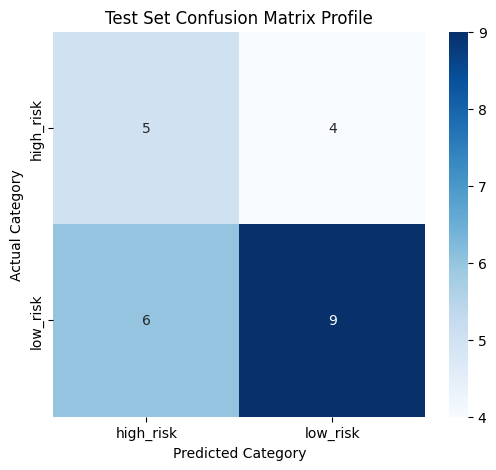

In [7]:
# ==========================================
# PHASE 5: EVALUATION ON UNSEEN HOLD-OUTS
# ==========================================
print("\n--- Starting Phase 5: Evaluation ---")
y_pred_prob = model.predict(test_gen)
y_pred = (y_pred_prob > 0.5).astype(int)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print("\nFinal Test Metrics Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Render visual performance matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Test Set Confusion Matrix Profile')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

In [ ]:
# ==========================================
# PHASE 6: GRAD-CAM INTERPRETABILITY TEST
# ==========================================
print("\n--- Starting Phase 6: Running Explainable Inference Test ---")

def execute_gradcam_inference(image_path, model_path='/kaggle/working/oral_risk_mobilenet.keras'):
    loaded_model = tf.keras.models.load_model(model_path)
    
    # Preprocess image patch
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_tensor = np.expand_dims(img_array, axis=0)
    
    # Generate predictive probability
    pred_prob = loaded_model.predict(img_tensor, verbose=0)[0][0]
    assigned_diagnosis = "LOW RISK" if pred_prob > 0.5 else "HIGH RISK"
    
    # Extract structural convolutional target layers
    target_conv_layer = None
    for layer in reversed(loaded_model.layers):
        if len(layer.output_shape) == 4:
            target_conv_layer = layer.name
            break
            
    grad_features_model = tf.keras.models.Model(
        [loaded_model.inputs], [loaded_model.get_layer(target_conv_layer).output, loaded_model.output]
    )
    
    # Monitor feature mapping gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_features_model(img_tensor)
        target_class_index = tf.argmax(predictions[0])
        class_activation_channel = predictions[:, target_class_index]

    gradients = tape.gradient(class_activation_channel, conv_outputs)
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    
    # Calculate activations
    heatmap = conv_outputs @ pooled_gradients[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    # Reconstruct activation visual map
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Superimpose original canvas over heatmap weights
    blended_canvas = heatmap_colored * 0.4 + img_array * 255 * 0.6
    blended_canvas = np.clip(blended_canvas, 0, 255).astype('uint8')

    # Present visualization graphs
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1)
    plt.title("Input Biopsy Frame")
    plt.imshow(img_array)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Spatial Activation Core (Heatmap)")
    plt.imshow(heatmap_colored)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title(f"Decision Map Target: {assigned_diagnosis}")
    plt.imshow(blended_canvas)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run interpretability test directly on the first test sample
sample_test_path = test_df.iloc[0]['absolute_path']
execute_gradcam_inference(sample_test_path)

In [4]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import warnings

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Mute cosmetic warnings for a clean output log
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="The structure of `inputs` doesn't match")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

# ==========================================
# PHASE 1: DATA SETUP (FULL 3,763 PATCH UNLOCK)
# ==========================================
print("--- Starting Phase 1: Data Setup (Unlocking Full Dataset) ---")
BASE_PATH = '/kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/'

# 1. Load the Master Patient Data to get the true diagnoses
CSV_PATH = os.path.join(BASE_PATH, 'ndb-ufes.csv')
master_df = pd.read_csv(CSV_PATH)

# Standardize the master paths to use as matching keys
master_df['base_id'] = master_df['path'].apply(lambda x: str(x).replace('.jpg', '').replace('.png', ''))
master_df['risk_label'] = master_df['diagnosis'].apply(lambda x: 'high_risk' if 'carcinoma' in str(x).lower() or 'with dysplasia' in str(x).lower() else 'low_risk')

# Create a dictionary linking the patient ID to the risk level
master_label_dict = dict(zip(master_df['base_id'], master_df['risk_label']))

# 2. Hunt for ALL 3,763 patches in the directory
patch_dir = os.path.join(BASE_PATH, 'patch')
all_patch_paths = []

print("Scanning for patch files...")
for root, dirs, files in os.walk(patch_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_patch_paths.append(os.path.join(root, file))
            
print(f"SUCCESS: Discovered {len(all_patch_paths)} total image patches!")

# 3. Map Patches to their Clinical Labels
patch_data = []
for patch_path in all_patch_paths:
    filename = os.path.basename(patch_path)
    assigned_label = None
    
    # Check if the patch filename contains a known patient/slide ID
    for base_id, label in master_label_dict.items():
        if base_id in filename:
            assigned_label = label
            break
                
    if assigned_label:
        patch_data.append({'absolute_path': patch_path, 'risk_label': assigned_label})

# 4. Finalize the Massive Dataframe
df = pd.DataFrame(patch_data)
print(f"Successfully mapped {len(df)} patches to clinical labels.")

# Show the new balance
print("\nNew Dataset Distribution:")
print(df['risk_label'].value_counts())

# Convert labels to strict integers for CutMix blending (0 = high_risk, 1 = low_risk)
label_map = {'high_risk': 0, 'low_risk': 1}
df['risk_int'] = df['risk_label'].map(label_map)


# ==========================================
# PHASE 2: CUTMIX AUGMENTATION ENGINE
# ==========================================
def get_rand_bbox(width, height, l):
    """Generates random bounding box coordinates for the CutMix patch"""
    r_x = np.random.randint(width)
    r_y = np.random.randint(height)
    r_l = np.sqrt(1 - l)
    w = int(width * r_l)
    h = int(height * r_l)
    bbx1 = np.clip(r_x - w // 2, 0, width)
    bby1 = np.clip(r_y - h // 2, 0, height)
    bbx2 = np.clip(r_x + w // 2, 0, width)
    bby2 = np.clip(r_y + h // 2, 0, height)
    return bbx1, bby1, bbx2, bby2

def cutmix_generator(base_generator, class_weights, alpha=1.0):
    """Intercepts batches, applies CutMix, and dynamically blends sample weights"""
    while True:
        X, y = next(base_generator)
        batch_size = X.shape[0]
        
        if batch_size < 2:
            sw = np.array([class_weights[int(label)] for label in y])
            yield X, y, sw
            continue

        indices = np.random.permutation(batch_size)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        lam = np.random.beta(alpha, alpha)
        bbx1, bby1, bbx2, bby2 = get_rand_bbox(224, 224, lam)

        X_mixed = X.copy()
        X_mixed[:, bby1:bby2, bbx1:bbx2, :] = X_shuffled[:, bby1:bby2, bbx1:bbx2, :]

        lam_adjusted = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (224.0 * 224.0))
        y_mixed = y * lam_adjusted + y_shuffled * (1 - lam_adjusted)

        sw1 = np.array([class_weights[int(label)] for label in y])
        sw2 = np.array([class_weights[int(label)] for label in y_shuffled])
        sw_mixed = sw1 * lam_adjusted + sw2 * (1 - lam_adjusted)

        yield X_mixed, y_mixed, sw_mixed


# ==========================================
# PHASE 3: 5-FOLD CROSS VALIDATION
# ==========================================
print("\n--- Starting Phase 3: 5-Fold Cross Validation ---")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_metrics = [] 

CUSTOM_THRESHOLD = 0.35
BATCH_SIZE = 8

def build_model():
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = True
    for layer in base_model.layers[:-20]:
        layer.trainable = False
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

for fold, (train_idx, val_idx) in enumerate(skf.split(df['absolute_path'], df['risk_int'])):
    print(f"\n========== STARTING FOLD {fold + 1}/5 ==========")
    
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]
    
    weights = compute_class_weight('balanced', classes=np.unique(train_df['risk_int']), y=train_df['risk_int'])
    class_weight_dict = {int(k): float(v) for k, v in enumerate(weights)}
    
    train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True, vertical_flip=True)
    val_datagen = ImageDataGenerator(rescale=1./255)
    
    raw_train_gen = train_datagen.flow_from_dataframe(
        train_df, x_col='absolute_path', y_col='risk_int', target_size=(224, 224), 
        batch_size=BATCH_SIZE, class_mode='raw'
    )
    val_gen = val_datagen.flow_from_dataframe(
        val_df, x_col='absolute_path', y_col='risk_int', target_size=(224, 224), 
        batch_size=BATCH_SIZE, class_mode='raw', shuffle=False
    )
    
    cutmix_train_gen = cutmix_generator(raw_train_gen, class_weight_dict)
    
    model = build_model()
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    steps = len(train_df) // BATCH_SIZE
    
    model.fit(
        cutmix_train_gen, 
        steps_per_epoch=steps,
        validation_data=val_gen, 
        epochs=12, 
        callbacks=[early_stop],
        verbose=1
    )
    
    print(f"Evaluating Fold {fold + 1}...")
    y_pred_prob = model.predict(val_gen, verbose=0)
    y_pred = (y_pred_prob > CUSTOM_THRESHOLD).astype(int)
    y_true = val_gen.labels
    
    if fold == 4:
        model.save('/kaggle/working/oral_risk_mobilenet_cv.keras')
        
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    high_risk_recall = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    fold_metrics.append({'Fold': fold + 1, 'Accuracy': accuracy, 'High_Risk_Recall': high_risk_recall})
    print(f"--> Fold {fold + 1} High_Risk Recall: {high_risk_recall:.2f} | Accuracy: {accuracy:.2f}")


# ==========================================
# PHASE 4: FINAL ABSOLUTE PERFORMANCE
# ==========================================
print("\n==========================================")
print("      FINAL 5-FOLD CV TRUE METRICS        ")
print("==========================================")
metrics_df = pd.DataFrame(fold_metrics)
print(metrics_df.to_string(index=False))

avg_acc = metrics_df['Accuracy'].mean()
avg_rec = metrics_df['High_Risk_Recall'].mean()

print("------------------------------------------")
print(f"TRUE AVERAGE ACCURACY:   {avg_acc:.2f}")
print(f"TRUE AVERAGE RECALL:     {avg_rec:.2f}")
print("------------------------------------------\n")


# ==========================================
# PHASE 5: GRAD-CAM INTERPRETABILITY TEST 
# ==========================================
print("--- Starting Phase 5: Running Explainable Inference Test ---")

def execute_gradcam_inference(image_path, model_path='/kaggle/working/oral_risk_mobilenet_cv.keras'):
    loaded_model = tf.keras.models.load_model(model_path)
    
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_tensor = np.expand_dims(img_array, axis=0)
    
    pred_prob = loaded_model.predict(img_tensor, verbose=0)[0][0]
    assigned_diagnosis = "HIGH RISK" if pred_prob <= CUSTOM_THRESHOLD else "LOW RISK"
    confidence = (1.0 - pred_prob) * 100 if assigned_diagnosis == "HIGH RISK" else pred_prob * 100
    
    target_conv_layer = None
    for layer in reversed(loaded_model.layers):
        if "conv" in layer.name.lower() or "activation" in layer.name.lower():
            if hasattr(layer, 'filters') or "Conv2D" in str(type(layer)):
                target_conv_layer = layer.name
                break
    if not target_conv_layer:
        target_conv_layer = "out_relu" 
            
    grad_features_model = tf.keras.models.Model(
        inputs=loaded_model.input, 
        outputs=[loaded_model.get_layer(target_conv_layer).output, loaded_model.output]
    )
    
    with tf.GradientTape(persistent=True) as tape:
        conv_outputs, predictions = grad_features_model(img_tensor)
        class_activation_channel = predictions[:, 0]

    gradients = tape.gradient(class_activation_channel, conv_outputs)
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    
    heatmap = conv_outputs @ pooled_gradients[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    del tape

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    blended_canvas = heatmap_colored * 0.4 + img_array * 255 * 0.6
    blended_canvas = np.clip(blended_canvas, 0, 255).astype('uint8')

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1)
    plt.title("Input Biopsy Frame")
    plt.imshow(img_array)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Spatial Activation Core")
    plt.imshow(heatmap_colored)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title(f"{assigned_diagnosis} ({confidence:.1f}%)")
    plt.imshow(blended_canvas)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the inference on a random image from the dataset to verify it works
sample_test_path = df['absolute_path'].iloc[0]
execute_gradcam_inference(sample_test_path)

--- Starting Phase 1: Data Setup (Unlocking Full Dataset) ---
Scanning for patch files...
SUCCESS: Discovered 3763 total image patches!
Successfully mapped 237 patches to clinical labels.

New Dataset Distribution:
risk_label
low_risk     148
high_risk     89
Name: count, dtype: int64

--- Starting Phase 3: 5-Fold Cross Validation ---

========== STARTING FOLD 1/5 ==========
Found 189 validated image filenames.
Found 48 validated image filenames.
Epoch 1/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 27s 564ms/step - accuracy: 0.3449 - loss: 0.8095 - val_accuracy: 0.6458 - val_loss: 0.7098
Epoch 2/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - accuracy: 0.3767 - loss: 0.6741 - val_accuracy: 0.5417 - val_loss: 0.7296
Epoch 3/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.4050 - loss: 0.7482 - val_accuracy: 0.5000 - val_loss: 0.8359
Epoch 4/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - accuracy: 0.3710 - loss: 0.7367 - val_accuracy: 0.5417 - val_loss: 0.7113
Epoch 5/12
23/23 ━━━━━━━━━━━━━━━━━━

KeyboardInterrupt: 